In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [20]:
data = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# Convert to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Sort data
data = data.sort_values('Order Date')

# Display first rows
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7980,7981,CA-2014-103800,2014-01-03,1/7/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
739,740,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
740,741,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
741,742,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
1759,1760,CA-2014-141817,2014-01-05,1/12/2014,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [21]:
# Check missing values
data.isnull().sum()

# Fill missing values (optional)
data.ffill(inplace=True)

In [22]:
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [23]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

daily_sales.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek
0,2014-01-03,16.448,2014,1,3,4
1,2014-01-04,288.060,2014,1,4,5
2,2014-01-05,19.536,2014,1,5,6
3,2014-01-06,4407.100,2014,1,6,0
4,2014-01-07,87.158,2014,1,7,1


In [24]:
# Lag features (previous sales)
daily_sales['Lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['Lag_2'] = daily_sales['Sales'].shift(2)
daily_sales['Lag_3'] = daily_sales['Sales'].shift(3)

# Rolling mean (trend)
daily_sales['Rolling_Mean_3'] = daily_sales['Sales'].rolling(window=3).mean()

# Remove null values created by lagging
daily_sales.dropna(inplace=True)

In [25]:
X = daily_sales[['Year', 'Month', 'Day', 'DayOfWeek',
                 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']]

y = daily_sales['Sales']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [27]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
predictions = model.predict(X_test)

In [29]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 559.3024210242917
RMSE: 1065.9645074696175
R2 Score: 0.8137015250016915


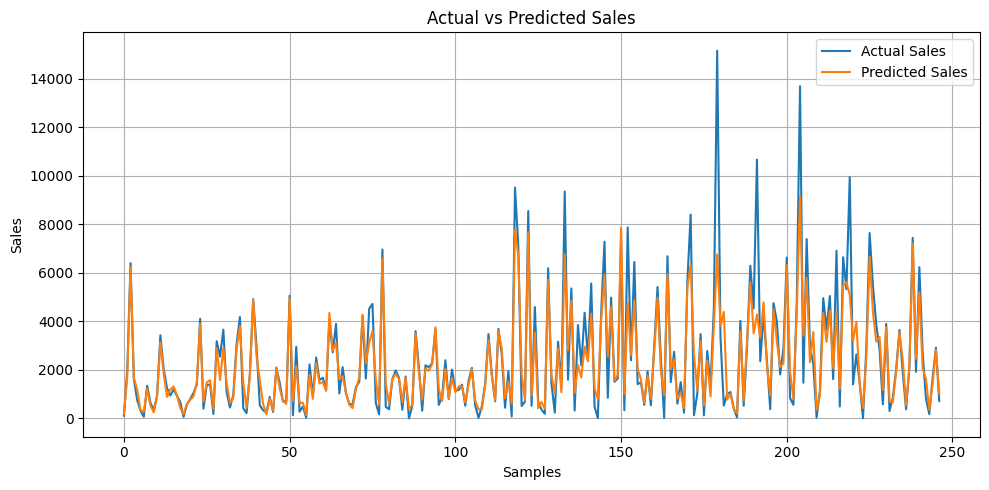

In [30]:
y_pred = model.predict(X_test)
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()

plt.grid()

plt.tight_layout()
plt.show()

In [31]:
# Take last known sales values
last_data = daily_sales.tail(3)

future_dates = pd.date_range(
    start=daily_sales['Order Date'].max(), periods=30
)

future_predictions = []

# Initialize lag values
lag_1 = last_data['Sales'].iloc[-1]
lag_2 = last_data['Sales'].iloc[-2]
lag_3 = last_data['Sales'].iloc[-3]

for date in future_dates:
    
    year = date.year
    month = date.month
    day = date.day
    dayofweek = date.dayofweek
    
    # Rolling mean
    rolling_mean = (lag_1 + lag_2 + lag_3) / 3
    
    # Create DataFrame with correct feature names
    X_future = pd.DataFrame({
        'Year': [year],
        'Month': [month],
        'Day': [day],
        'DayOfWeek': [dayofweek],
        'Lag_1': [lag_1],
        'Lag_2': [lag_2],
        'Lag_3': [lag_3],
        'Rolling_Mean_3': [rolling_mean]
    })
    
    # Predict
    pred = model.predict(X_future)[0]
    
    future_predictions.append(pred)
    
    # Update lag values
    lag_3 = lag_2
    lag_2 = lag_1
    lag_1 = pred

# Store results
future_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_predictions
})

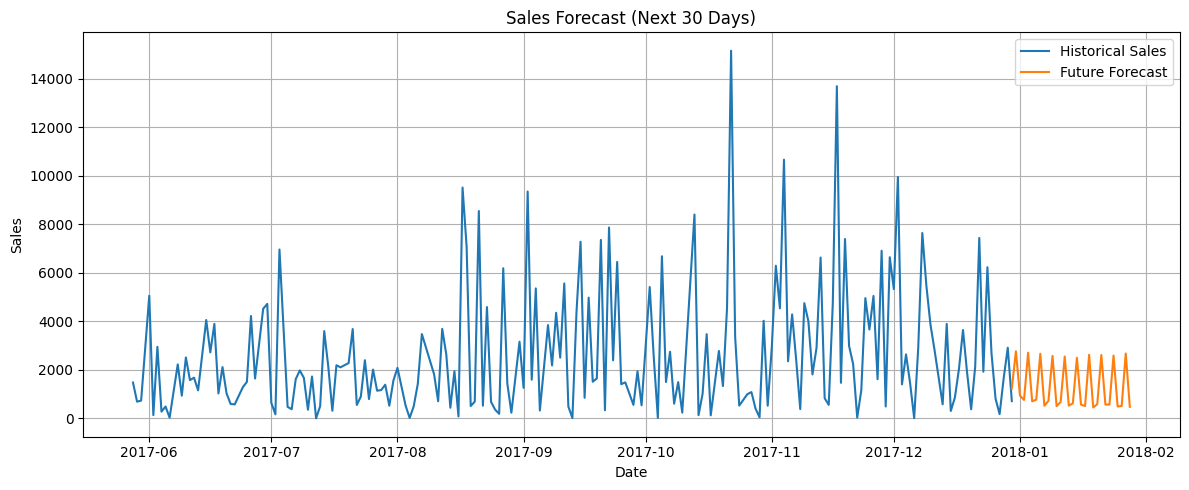

In [32]:
plt.figure(figsize=(12,5))

# Plot last part of historical data (zoomed)
plt.plot(daily_sales['Order Date'].tail(200),
         daily_sales['Sales'].tail(200),
         label='Historical Sales')

# Plot forecast
plt.plot(future_df['Date'],
         future_df['Forecast'],
         label='Future Forecast')

plt.title("Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.grid()

plt.tight_layout()
plt.show()